In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification


In [3]:
X,y=make_classification(n_features=5,n_redundant=0,n_informative=5,n_clusters_per_class=1)

In [4]:
df=pd.DataFrame(X,columns=['col1','col2','col3','col4','col5'])
df['target']=y
print(df.shape)

(100, 6)


In [5]:
df.head()

,col1,col2,col3,col4,col5,target
0,-2.993271,1.438084,1.311509,0.685545,-1.319168,1
1,-0.102702,0.989520,0.551881,1.555258,-0.757283,1
2,-1.997063,0.648848,3.010486,1.623027,-2.782669,1
3,-3.099637,1.361154,-0.803865,0.402986,-0.681548,1
4,1.630457,0.236588,-0.373564,-2.591709,-1.838764,0


In [6]:
def sample_rows(df,percent):
    return df.sample(int(percent*df.shape[0]),replace=True)

In [7]:
import random
def sample_features(df,percent):
    cols=random.sample(df.columns.tolist()[:-1],int(percent*df.shape[1]))
    return df[cols]

In [8]:
def combined_sampling(df,row_percent,col_percent):
    new_df=sample_rows(df,row_percent)
    return sample_features(new_df,col_percent)

In [10]:
df1=sample_rows(df,0.1)
df1

,col1,col2,col3,col4,col5,target
89,-1.215697,-0.015224,2.371981,0.413644,-2.481360,1
82,0.680335,-1.773292,-1.089159,-1.592974,-0.206007,0
62,1.413964,-2.165388,-0.467390,-0.499901,-0.862309,0
3,-3.099637,1.361154,-0.803865,0.402986,-0.681548,1
73,-0.418020,-0.122994,0.540493,1.534393,-2.109136,1
61,-0.810336,0.452126,1.214799,0.599618,-1.432824,1
97,1.719904,-0.794746,-0.399148,-0.925047,-1.438059,0
33,-0.318027,1.602879,1.220540,2.003930,-0.626956,1
66,-0.263882,1.064961,-0.106551,1.243392,-0.375338,1
63,-1.867194,2.067625,2.707766,0.630653,-0.625541,1


In [13]:
df2=sample_rows(df,0.1)
df2

,col1,col2,col3,col4,col5,target
79,-2.481398,1.099190,0.356192,0.734936,-1.089947,1
83,0.140495,-0.874664,-1.819118,-1.324998,1.273505,0
99,0.623709,0.461167,1.038410,1.381452,-1.116597,1
35,0.492402,0.094509,-0.947615,3.864565,-1.877492,1
63,-1.867194,2.067625,2.707766,0.630653,-0.625541,1
53,-0.018679,1.205744,1.710991,1.017193,-0.663982,1
65,2.595655,-0.924392,0.810615,2.825418,-2.588677,1
8,0.221695,0.573637,-0.351789,3.621571,-1.660371,1
96,0.095817,-2.124108,-1.661413,-0.433699,-1.038846,0
79,-2.481398,1.099190,0.356192,0.734936,-1.089947,1


In [14]:
df3=sample_rows(df,0.1)
df3

,col1,col2,col3,col4,col5,target
45,-2.885268,1.426683,2.108094,-0.042729,-1.286974,1
3,-3.099637,1.361154,-0.803865,0.402986,-0.681548,1
91,2.918142,2.456658,0.376375,-2.135693,-1.989760,0
16,1.561913,-2.843183,-0.337738,0.040866,-1.062155,0
38,0.705905,-0.539323,-1.399042,-0.927305,-1.677395,0
7,-0.717994,0.101606,0.423445,2.040945,-2.118176,1
62,1.413964,-2.165388,-0.467390,-0.499901,-0.862309,0
66,-0.263882,1.064961,-0.106551,1.243392,-0.375338,1
81,1.960822,-2.841760,0.136789,-1.109267,-0.620622,0
26,-1.667529,1.958118,2.487457,-0.556110,-0.013114,1


In [15]:
df1.shape

(10, 6)

In [19]:
from sklearn.tree import DecisionTreeClassifier
clf1=DecisionTreeClassifier()
clf2=DecisionTreeClassifier()
clf3=DecisionTreeClassifier()

In [21]:
clf1.fit(df1.iloc[:,0:4],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:4],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:4],df3.iloc[:,-1])

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [23]:
from sklearn.tree import plot_tree


[Text(0.5, 0.75, 'x[0] <= 0.208\ngini = 0.42\nsamples = 10\nvalue = [3, 7]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 7\nvalue = [0, 7]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.625, 0.5, '  False')]

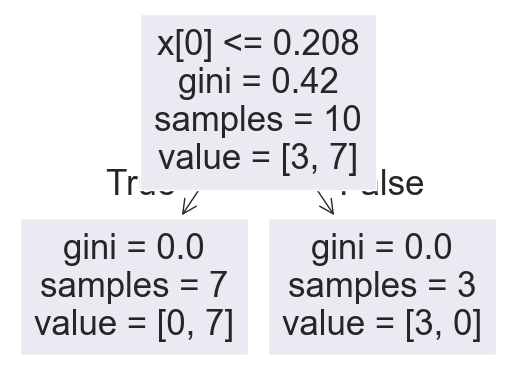

In [24]:
plot_tree(clf1)

[Text(0.5, 0.75, 'x[3] <= 0.098\ngini = 0.32\nsamples = 10\nvalue = [2, 8]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 8\nvalue = [0, 8]'),
 Text(0.625, 0.5, '  False')]

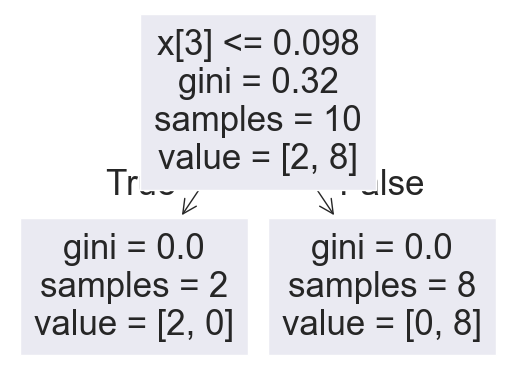

In [25]:
plot_tree(clf2)

[Text(0.5, 0.75, 'x[0] <= 0.221\ngini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 5\nvalue = [0, 5]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 5\nvalue = [5, 0]'),
 Text(0.625, 0.5, '  False')]

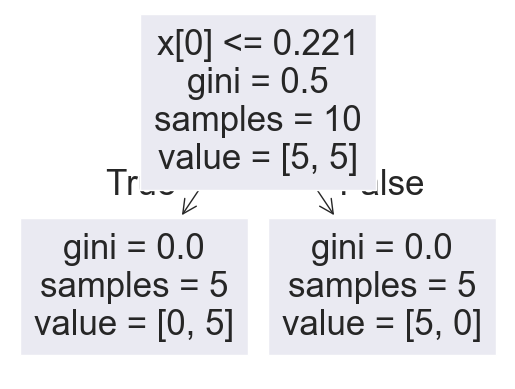

In [26]:
plot_tree(clf3)